Import bibliotek

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option('display.float_format', '{:,.2f}'.format)

Załadowanie danych

In [ ]:
df = pd.read_csv("../data/sales_random.csv")

Pierwsze 5 obserwacji

In [41]:
df.head()

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city,lat,lon
0,247604,146511_8.1105.104_BUD.66_LOK,"418,433.00","13,471.76",2,2,mieszkalna,PLN,31.06,2025-11-19,Ulica Krzewna 9,Warszawa,52.27,21.08
1,247605,146511_8.1105.104_BUD.30_LOK,"912,136.20","14,443.96",2,4,mieszkalna,PLN,63.15,2025-11-19,Ulica Krzewna 9,Warszawa,52.27,21.08
2,246652,146519_8.0104.63_BUD.220_LOK,"780,000.00","17,067.83",9,2,mieszkalna,PLN,45.70,2025-11-19,Ulica Gwiaździsta 15A,Warszawa,52.28,20.98
3,2274823,146505_8.0809.1023_BUD.318_LOK,"950,000.00","25,503.36",8,2,mieszkalna,PLN,37.25,2025-11-19,Ulica Wołoska 3,Warszawa,52.18,21.00
4,2274808,146505_8.0809.1022_BUD.176_LOK,"926,994.56","22,283.52",5,2,mieszkalna,PLN,41.60,2025-11-19,Ulica Fabryki „tewa” 5,Warszawa,52.18,21.00


Informacje na temat zbioru

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_rcn_id    20000 non-null  int64  
 1   name           20000 non-null  str    
 2   amount         20000 non-null  float64
 3   amount_sqm     20000 non-null  float64
 4   floor_number   20000 non-null  int64  
 5   rooms_number   20000 non-null  int64  
 6   type           20000 non-null  str    
 7   currency       20000 non-null  str    
 8   size           20000 non-null  float64
 9   creation_date  20000 non-null  str    
 10  invest_name    20000 non-null  str    
 11  invest_city    20000 non-null  str    
 12  lat            20000 non-null  float64
 13  lon            20000 non-null  float64
dtypes: float64(5), int64(3), str(6)
memory usage: 2.1 MB


Licza unikatowych wartości w kolumnie 'type'

In [43]:
df['type'].value_counts()

type
mieszkalna    20000
Name: count, dtype: int64

Minimalna data

In [44]:
df['creation_date'].min()


'2016-11-10'

Maksymalna data

In [45]:
df['creation_date'].max()

'2025-11-19'

Statystyki zbiory na cechach numerycznych

In [46]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size,lat,lon
count,"20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","20,000.00","20,000.00"
mean,"162,115.63","667,426.44","11,659.72",3.93,2.72,57.13,52.23,21.00
std,"87,799.67","543,245.06","4,721.76",2.91,1.15,26.66,0.05,0.07
min,"52,050.00","68,494.00","2,300.00",-5.00,0.00,20.00,52.10,20.86
25%,"113,948.50","400,000.00","8,213.85",2.00,2.00,39.89,52.20,20.95
50%,"158,837.50","550,470.00","10,649.17",3.00,3.00,50.80,52.23,21.00
75%,"209,181.75","765,000.00","14,133.50",5.00,3.00,67.01,52.26,21.06
max,"2,274,881.00","31,750,000.00","59,156.35",51.00,23.00,624.34,52.36,21.25


Obserwacja z maksymalna ceną za m2

In [47]:
df[df['amount_sqm']==df['amount_sqm'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city,lat,lon
5256,214379,146510_8.0405.25.1_BUD.20_LOK,"12,860,000.00","59,156.35",5,1,mieszkalna,PLN,217.39,2023-11-21,Ulica Dynasy 22,Warszawa,52.24,21.02


Obserwacje z maksymalna ceną

In [48]:
df[df['amount']==df['amount'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city,lat,lon
3603,218558,146510_8.0606.108_BUD.20_LOK,"31,750,000.00","50,853.70",7,7,mieszkalna,PLN,624.34,2024-05-07,Ulica Szara 8,Warszawa,52.23,21.03


Obserwacja z maksymalna powierzchnią

In [49]:
df[df['size']==df['size'].max()]

,sale_rcn_id,name,amount,amount_sqm,floor_number,rooms_number,type,currency,size,creation_date,invest_name,invest_city,lat,lon
3603,218558,146510_8.0606.108_BUD.20_LOK,"31,750,000.00","50,853.70",7,7,mieszkalna,PLN,624.34,2024-05-07,Ulica Szara 8,Warszawa,52.23,21.03


Usunięcie wartości odstających na podstawie kryterium półtorakrotności rozstępu międzykwartylowego (IQR)

In [50]:
kolumny = ['amount','amount_sqm','size']
for i in kolumny:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    df = df[(df[i] >= Q1 - 1.5*IQR) & (df[i] <= Q3 + 1.5*IQR)]

df = df = df[df['rooms_number'] != 0]
df = df[df["floor_number"] >= 0]
df = df[df["rooms_number"] != 23]

In [51]:
df.describe()

,sale_rcn_id,amount,amount_sqm,floor_number,rooms_number,size,lat,lon
count,"17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00","17,379.00"
mean,"157,683.53","554,951.89","11,001.30",3.91,2.69,51.55,52.24,21.00
std,"69,389.62","229,441.22","3,698.68",2.62,0.92,16.34,0.05,0.07
min,"52,050.00","68,494.00","2,300.00",0.00,1.00,20.00,52.10,20.86
25%,"110,323.50","382,323.62","8,100.00",2.00,2.00,38.94,52.20,20.95
50%,"153,072.00","516,000.00","10,297.91",3.00,3.00,48.77,52.23,21.00
75%,"206,066.50","684,144.85","13,471.58",5.00,3.00,62.17,52.26,21.05
max,"2,274,829.00","1,310,000.00","21,718.15",35.00,8.00,100.83,52.36,21.25


Rozkład mieszkań w podziale na liczbę pokoi

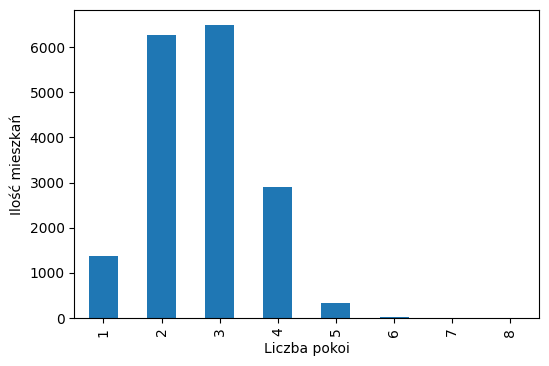

rooms_number
3    6502
2    6262
4    2894
1    1377
5     322
6      12
7       6
8       4
Name: count, dtype: int64

In [52]:
df['rooms_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Liczba pokoi')
plt.ylabel('Ilość mieszkań')
plt.show()
df["rooms_number"].value_counts()

Rozkład mieszkań w podziale na piętro

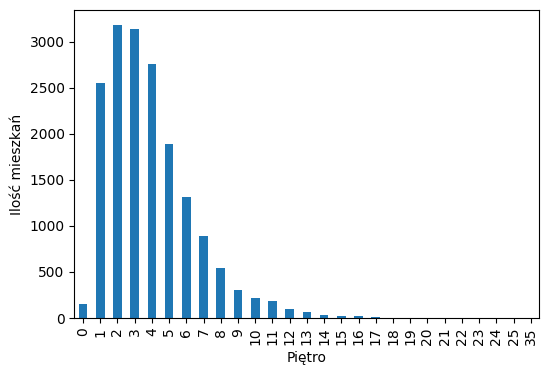

floor_number
2     3184
3     3140
4     2752
1     2552
5     1890
6     1308
7      887
8      543
9      299
10     215
11     186
0      153
12      95
13      60
14      32
16      26
15      20
17      12
18       5
20       4
19       4
22       3
24       3
21       2
23       2
25       1
35       1
Name: count, dtype: int64

In [53]:
df['floor_number'].value_counts().sort_index().plot(kind='bar', figsize=(6,4))
plt.xlabel('Piętro')
plt.ylabel('Ilość mieszkań')
plt.show()
df["floor_number"].value_counts()

Rozkład rozmiaru mieszkań

Text(0.5, 1.0, 'Rozkład rozmiaru mieszkań')

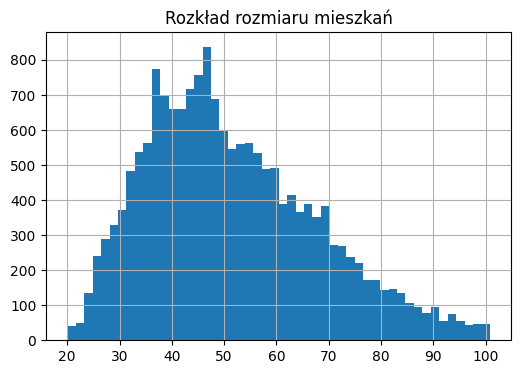

In [54]:
plt.figure(figsize=(6,4))
df["size"].hist(bins=50)
plt.title('Rozkład rozmiaru mieszkań')

Rozkład ceny za m2

Text(0.5, 1.0, 'Rozkład ceny za m2')

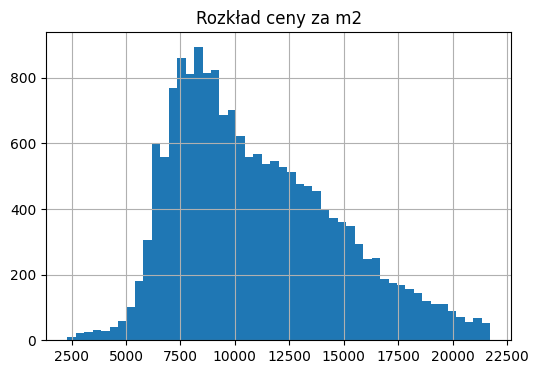

In [55]:
plt.figure(figsize=(6,4))
df["amount_sqm"].hist(bins=50)
plt.title('Rozkład ceny za m2')

In [56]:
round(df['amount_sqm'].mean(),0)


np.float64(11001.0)

In [57]:
round(df['amount_sqm'].median(),0)

np.float64(10298.0)

Średnie:
-rozmiar w podziale na liczbę pokoi
-cena za m2 w podziale na liczbę pokoi
-cena za m2 w podziale na piętro

In [58]:
gb = df.groupby('rooms_number')['size'].mean()
print(gb)
gb = df.groupby('rooms_number')['amount_sqm'].mean()
print(gb)
gb = df.groupby('floor_number')['amount_sqm'].mean()
print(gb)


rooms_number
1   31.60
2   41.32
3   56.16
4   69.34
5   80.91
6   82.34
7   82.27
8   76.42
Name: size, dtype: float64
rooms_number
1   12,168.09
2   11,593.05
3   10,701.59
4   10,024.34
5    9,562.14
6    7,454.22
7    6,978.73
8    9,460.08
Name: amount_sqm, dtype: float64
floor_number
0    10,409.83
1    10,464.41
2    10,820.33
3    11,038.87
4    11,164.04
5    11,208.90
6    11,307.15
7    11,320.41
8    11,220.26
9    11,648.98
10   11,090.05
11   11,001.20
12   11,169.53
13   10,651.62
14   12,198.48
15   12,522.49
16   12,155.12
17    9,519.19
18   10,164.84
19    8,656.36
20    9,085.43
21   10,057.47
22   12,481.66
23    8,495.28
24    9,278.57
25   19,108.28
35   19,682.86
Name: amount_sqm, dtype: float64


Wykres pudełkowy: cena za m2 w podziale na piętro

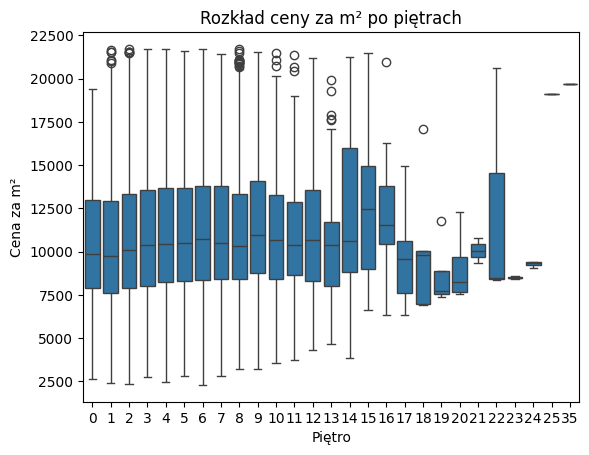

In [59]:
sns.boxplot(x='floor_number', y='amount_sqm', data=df)
plt.xlabel('Piętro')
plt.ylabel('Cena za m²')
plt.title('Rozkład ceny za m² po piętrach')
plt.show()

Dodanie kolumn miesiąc i rok

In [60]:
df["creation_date"] = pd.to_datetime(df["creation_date"])
df['month'] = df['creation_date'].dt.month
df['year'] = df['creation_date'].dt.year

Ceny m2 w perspektywie czasu

<Axes: xlabel='creation_date'>

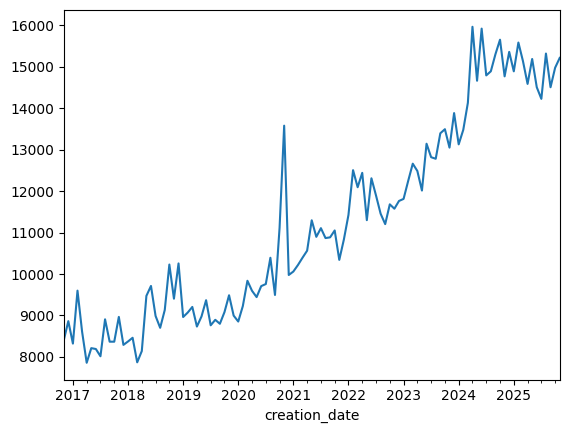

In [61]:
df.groupby(df['creation_date'].dt.to_period('M'))['amount_sqm'].mean().plot()

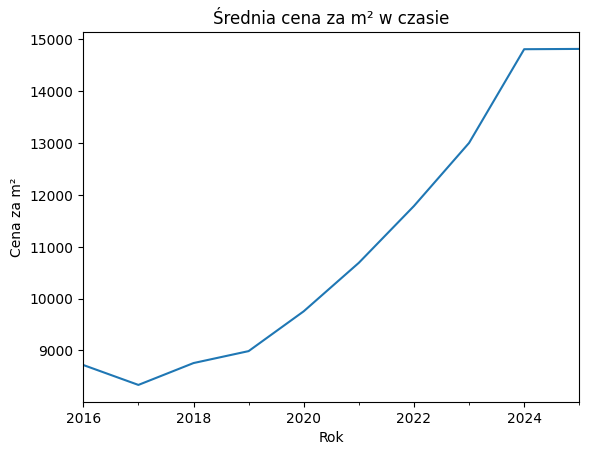

In [62]:
df.groupby(df['creation_date'].dt.to_period('Y'))['amount_sqm'].mean().plot()
plt.title('Średnia cena za m² w czasie')
plt.ylabel('Cena za m²')
plt.xlabel('Rok')
plt.show()

In [63]:
df['creation_date'].dt.year.value_counts().sort_index()

creation_date
2016     180
2017    2267
2018    1608
2019    2537
2020    1834
2021    2231
2022    1508
2023    1612
2024    1814
2025    1788
Name: count, dtype: int64

In [64]:
df.info()

<class 'pandas.DataFrame'>
Index: 17379 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sale_rcn_id    17379 non-null  int64         
 1   name           17379 non-null  str           
 2   amount         17379 non-null  float64       
 3   amount_sqm     17379 non-null  float64       
 4   floor_number   17379 non-null  int64         
 5   rooms_number   17379 non-null  int64         
 6   type           17379 non-null  str           
 7   currency       17379 non-null  str           
 8   size           17379 non-null  float64       
 9   creation_date  17379 non-null  datetime64[us]
 10  invest_name    17379 non-null  str           
 11  invest_city    17379 non-null  str           
 12  lat            17379 non-null  float64       
 13  lon            17379 non-null  float64       
 14  month          17379 non-null  int32         
 15  year           17379 non-null  int3

In [65]:
cpi = pd.read_csv("../data/inflacja_prepared.csv", index_col=0).reset_index(drop=True)

In [66]:
cpi.head()

,Rok,Miesiąc,Wartość inflacji,date
0,2025,1,4.90,2025-01-01
1,2025,2,4.90,2025-02-01
2,2025,3,4.90,2025-03-01
3,2025,4,4.30,2025-04-01
4,2025,5,4.00,2025-05-01


In [67]:
dfp = df.merge(
    cpi[["Rok", "Miesiąc", "Wartość inflacji"]],
    left_on=["year", "month"],
    right_on=["Rok", "Miesiąc"],
    how="left"
).drop(columns=["Rok", "Miesiąc"])

In [68]:
dfp.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sale_rcn_id       17379 non-null  int64         
 1   name              17379 non-null  str           
 2   amount            17379 non-null  float64       
 3   amount_sqm        17379 non-null  float64       
 4   floor_number      17379 non-null  int64         
 5   rooms_number      17379 non-null  int64         
 6   type              17379 non-null  str           
 7   currency          17379 non-null  str           
 8   size              17379 non-null  float64       
 9   creation_date     17379 non-null  datetime64[us]
 10  invest_name       17379 non-null  str           
 11  invest_city       17379 non-null  str           
 12  lat               17379 non-null  float64       
 13  lon               17379 non-null  float64       
 14  month             17379 non-null 

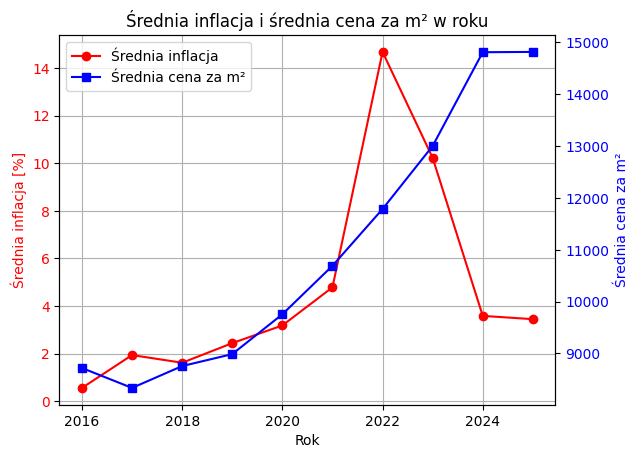

In [69]:
# Grupowanie po roku i liczenie średnich
yearly = dfp.groupby("year").agg({
    "Wartość inflacji": "mean",      # średnia inflacja
    "amount_sqm": "mean"    # średnia cena za m2
}).reset_index()

# Tworzymy wykres z podwójną osią Y
fig, ax1 = plt.subplots()

# Linia średniej inflacji
color = 'red'
ax1.set_xlabel('Rok')
ax1.set_ylabel('Średnia inflacja [%]', color=color)
ax1.plot(yearly['year'], yearly['Wartość inflacji'], color=color, marker='o', label='Średnia inflacja')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# Druga oś Y dla średniej ceny za m²
ax2 = ax1.twinx()
color = 'blue'
ax2.set_ylabel('Średnia cena za m²', color=color)
ax2.plot(yearly['year'], yearly['amount_sqm'], color=color, marker='s', label='Średnia cena za m²')
ax2.tick_params(axis='y', labelcolor=color)

# Dodanie legendy
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Średnia inflacja i średnia cena za m² w roku')
plt.show()

In [70]:
CENTER_LAT, CENTER_LON = 52.2297, 21.0122

def haversine(lat, lon, clat=CENTER_LAT, clon=CENTER_LON):
    R = 6371
    dlat = np.radians(lat - clat)
    dlon = np.radians(lon - clon)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat)) * np.cos(np.radians(clat)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

dfp["dist_center_km"] = haversine(dfp["lat"], dfp["lon"])

In [ ]:
dfp = dfp[['amount','floor_number','rooms_number','size','month','year','Wartość inflacji','lat','lon','dist_center_km']]

In [72]:
dfp.to_csv("../data/data_processed.csv")